In [1]:
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph
from langgraph.graph import START, END
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
#from typing import TypedDict, List, Dict, Any,Annotated

from langgraph.checkpoint.memory import MemorySaver
memory= MemorySaver()


from langgraph.types import interrupt,Command

/home/anjucv/.cache/pypoetry/virtualenvs/rag-task1-_QzYQtjV-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
import numpy as np

In [ ]:
from langchain_openai import ChatOpenAI
from langchain.tools import tool

In [4]:
from dotenv import load_dotenv

load_dotenv()

True

In [6]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4.1-mini")

In [7]:
llm

ChatOpenAI(profile={'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x7b417aa868a0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7b417a019670>, root_client=<openai.OpenAI object at 0x7b417aa85130>, root_async_client=<openai.AsyncOpenAI object at 0x7b417a91b4a0>, model_name='gpt-4.1-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [7]:
#llm.invoke('who is president of india')

In [8]:
# create tools

In [8]:
@tool
def load_stock_data(file_path: str) -> str:
    """
    Load stock data from CSV and return closing prices.
    """
    df = pd.read_csv(file_path)
    return str(df["close"].tolist())


@tool
def calculate_moving_average(prices: str) -> str:
    """
    Calculate moving average from price list.
    Input must be a list string.
    """
    import ast
    prices = ast.literal_eval(prices)
    ma = pd.Series(prices).rolling(3).mean().tolist()
    return str(ma)


@tool
def trend_strength(prices: str) -> str:
    """
    Calculate trend strength using price volatility and slope.

    Returns:
    - STRONG
    - MODERATE
    - WEAK
    """
    import ast
    import numpy as np

    prices = ast.literal_eval(prices)

    # slope (trend direction strength)
    x = np.arange(len(prices))
    slope = np.polyfit(x, prices, 1)[0]

    # volatility
    volatility = np.std(prices)

    if abs(slope) > 1 and volatility < 2:
        return "STRONG"
    elif abs(slope) > 0.3:
        return "MODERATE"
    else:
        return "WEAK"
    
@tool
def detect_spike(prices: str) -> str:
    """
    Detect sudden spikes or drops in price.

    Returns:
    - SPIKE UP
    - SPIKE DOWN
    - NO SPIKE
    """
    import ast

    prices = ast.literal_eval(prices)

    for i in range(1, len(prices)):
        change = (prices[i] - prices[i-1]) / prices[i-1]

        if change > 0.05:
            return "SPIKE UP"
        elif change < -0.05:
            return "SPIKE DOWN"

    return "NO SPIKE"

In [10]:


# result = detect_spike.invoke({
#     "prices": "[100, 102, 70, 106, 80]"
# })

# print(result)

In [11]:
# define state

In [7]:
from typing import TypedDict, List
from langchain_core.messages import BaseMessage

class AgentState(TypedDict):
    messages: List[BaseMessage]
    next_agent: str
    task_complete: bool
    file_paths: dict   

In [13]:
# tool exicution node

In [ ]:


from langgraph.prebuilt import ToolNode

# Register your tools here
tools = [
    load_stock_data,
    calculate_moving_average,
    trend_strength,
    detect_spike
]

tool_node = ToolNode(tools)

def execute_tools(state: AgentState):
    """
    Executes tool calls if present in last message.
    """
    last_message = state["messages"][-1]

    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return tool_node.invoke(state)

    return state

In [15]:
# data loader agents

In [16]:
from langchain_core.messages import SystemMessage

def data_loader_agent(state: AgentState):
    file_paths = state.get("file_paths", {})

    content = "Load stock data for:\n"
    for name, path in file_paths.items():
        content += f"{name}: {path}\n"

    system_msg = SystemMessage(
        content="Use load_stock_data tool for each file."
    )

    llm_with_tools = llm.bind_tools([load_stock_data])

    response = llm_with_tools.invoke(
        [system_msg, HumanMessage(content=content)]
    )
    print(response)

    return {
        "messages": [response],
        "next_agent": "analyst"
    }

In [17]:
# analyst agent

In [18]:
from langchain_core.messages import  AIMessage

In [19]:
def analyst_agent(state: AgentState):

    print("\n--- DEBUG analyst input ---")
    for m in state["messages"]:
        print(m.type, ":", m.content)
    print("---------------------------\n")

    # Extract only raw price lists
    price_data = []

    for m in state["messages"]:
        if m.type == "tool":
            content = m.content.strip()
            if content.startswith("[") and content.endswith("]"):
                price_data.append(content)

    results = []

    #ll 3 tools for each stock
    for data in price_data:
        ma = calculate_moving_average.invoke({"prices": data})
        trend = trend_strength.invoke({"prices": data})
        spike = detect_spike.invoke({"prices": data})

        results.append(
            f"Stock:\n"
            f"Prices: {data}\n"
            f"Moving Avg: {ma}\n"
            f"Trend: {trend}\n"
            f"Spike: {spike}\n"
        )

    final_analysis = "\n\n".join(results)

    return {
        "messages": [AIMessage(content=final_analysis)],
        "next_agent": "comparator"
    }

In [20]:
# comparator agent

In [21]:
#from langchain_core.messages import HumanMessage

def comparator_agent(state: AgentState):
    """
    Compares multiple stocks
    """

    print("\n--- DEBUG comparator input ---")
    for m in state["messages"]:
        print(m.type, ":", m.content)
    print("--------------------------------\n")

    #Extract only AI/Human messages
    clean_messages = [
        m for m in state["messages"]
        if m.type in ("human", "ai")
    ]

    system_msg = SystemMessage(
        content=(
            "You are a stock comparison expert.\n"
            "Compare multiple stocks based on:\n"
            "- Trend\n"
            "- Stability\n"
            "- Spike behavior\n"
            "Give a clear comparison."
        )
    )

    response = llm.invoke([system_msg] + clean_messages)
    print(response)

    return {
        "messages": [response],
        "next_agent": "summarizer"
    }

In [22]:
# summarizer agent

In [23]:
def summarizer_agent(state: AgentState):
    """
    Generates final summary
    """
    messages = state["messages"]

    system_msg = SystemMessage(
        content="You are a financial report writer. Summarize the analysis clearly."
    )

    response = llm.invoke([system_msg] + messages)

    return {
        "messages": [response],
        "next_agent": "end",
        "task_complete": True
    }

In [24]:
builder = StateGraph(AgentState)

builder.add_node("data_loader", data_loader_agent)
builder.add_node("analyst", analyst_agent)
builder.add_node("comparator", comparator_agent)
builder.add_node("summarizer", summarizer_agent)
builder.add_node("tools", tool_node)

builder.add_edge(START, "data_loader")

builder.add_conditional_edges("data_loader", tools_condition)
#builder.add_conditional_edges("analyst", tools_condition)

builder.add_edge("tools", "analyst")
builder.add_edge("analyst", "comparator")
builder.add_edge("comparator","summarizer")
builder.add_edge("summarizer", END)

graph = builder.compile(checkpointer=memory)

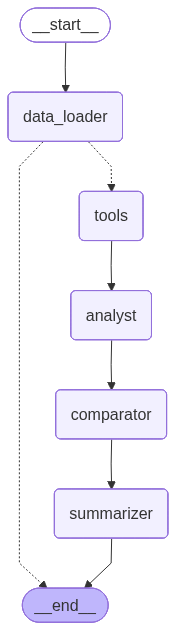

In [25]:
graph

In [26]:
result = graph.invoke(
    {
        "file_paths": {
            "HDFC": "stock_files/hdfc.csv",
            "INFY": "stock_files/infy.csv"
        }
    },
    config={"configurable": {"thread_id": "test-1"}}
)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 83, 'total_tokens': 141, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_b4212e551a', 'id': 'chatcmpl-DMvJhmOddvKdbKFN0d0Z2Ag3VxeMs', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019d1fda-979d-7892-ba2e-a4a1f78f0293-0' tool_calls=[{'name': 'load_stock_data', 'args': {'file_path': 'stock_files/hdfc.csv'}, 'id': 'call_t1tlz95NuttpawDVFgRTb2X1', 'type': 'tool_call'}, {'name': 'load_stock_data', 'args': {'file_path': 'stock_files/infy.csv'}, 'id': 'call_xbeUceAb7rGK1XtlmsCS0tkL', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 83, 'output_tokens': 58

In [27]:
print(result['messages'][0].content)

Both stocks exhibit moderate price trends with relative stability and no sharp spikes. Stock 1 demonstrates a gradual upward movement from 1610 to 1650, indicating steady growth potential. Stock 2 maintains a narrower range around 1510–1520, reflecting consistent stability but limited appreciation. Overall, Stock 1 may appeal more to investors seeking growth, while Stock 2 suits those prioritizing steadiness and low volatility.


# Superviser agent

In [9]:
from typing import TypedDict, List
from langchain_core.messages import BaseMessage

In [10]:
def print_state(state):
    print("\n===== STATE DEBUG =====")
    for k, v in state.items():
        if k == "messages":
            print("messages:", [m.type for m in v])
        else:
            print(k, ":", v)
    print("=======================\n")

In [11]:
from langchain_core.messages import BaseMessage

class AgentState(TypedDict, total=False):
    messages: List[BaseMessage]
    next_agent: str
    task_complete: bool
    file_paths: dict
    current_task: str
    analysis: str
    comparison: str
    final_report: str

In [13]:


from langgraph.prebuilt import ToolNode

# tools 
tools = [
    load_stock_data,
    calculate_moving_average,
    trend_strength,
    detect_spike
]

tool_node = ToolNode(tools)

def execute_tools(state: AgentState):
    """
    Executes tool calls if present in last message.
    """
    last_message = state["messages"][-1]

    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return tool_node.invoke(state)

    return state

In [15]:
from langchain_core.messages import SystemMessage

def data_loader_agent(state: AgentState):
    print_state(state)
    file_paths = state.get("file_paths", {})

    content = "Load stock data for:\n"
    for name, path in file_paths.items():
        content += f"{name}: {path}\n"

    system_msg = SystemMessage(
        content="Use load_stock_data tool for each file."
    )

    llm_with_tools = llm.bind_tools([load_stock_data])

    response = llm_with_tools.invoke(
        [system_msg, HumanMessage(content=content)]
    )
    print(response)

    return {
        "messages": state.get("messages", []) + [response],
        "next_agent": "supervisor"
    }

In [16]:
def analyst_agent(state: AgentState):
    print_state(state)

    print("\n--- DEBUG analyst input ---")
    for m in state["messages"]:
        print(m.type, ":", m.content)
    print("---------------------------\n")

    # Extract only raw price lists
    price_data = []

    for m in state["messages"]:
        if m.type == "tool":
            content = m.content.strip()
            if content.startswith("[") and content.endswith("]"):
                price_data.append(content)

    results = []

    #ll 3 tools for each stock
    for data in price_data:
        ma = calculate_moving_average.invoke({"prices": data})
        trend = trend_strength.invoke({"prices": data})
        spike = detect_spike.invoke({"prices": data})

        results.append(
            f"Stock:\n"
            f"Prices: {data}\n"
            f"Moving Avg: {ma}\n"
            f"Trend: {trend}\n"
            f"Spike: {spike}\n"
        )

    final_analysis = "\n\n".join(results)

    return {
        "messages": state["messages"] + [AIMessage(content=final_analysis)],
        "analysis": final_analysis, 
        "next_agent": "supervisor"
    }

In [17]:
#from langchain_core.messages import HumanMessage

def comparator_agent(state: AgentState):
    """
    Compares multiple stocks
    """
    print_state(state)
    print("\n--- DEBUG comparator input ---")
    for m in state["messages"]:
        print(m.type, ":", m.content)
    print("--------------------------------\n")

    analysis = state.get("analysis", "")

    #Extract only AI/Human messages
    clean_messages = [
        m for m in state["messages"]
        if m.type in ("human", "ai")
    ]

    system_msg = SystemMessage(
        content=(
            "You are a stock comparison expert.\n"
            "Compare multiple stocks based on:\n"
            "- Trend\n"
            "- Stability\n"
            "- Spike behavior\n"
            "Give a clear comparison."
        )
    )
 

    response = llm.invoke([
        system_msg,
        HumanMessage(content=analysis)
    ])


    return {
        "messages": state["messages"] + [response],
        "comparison": response.content,
        "next_agent": "supervisor"
    }

In [18]:
def summarizer_agent(state: AgentState):
    print_state(state)

    system_msg = SystemMessage(
        content="You are a financial report writer. Summarize the analysis clearly."
    )

    summary_input = f"""
    Analysis:
    {state.get("analysis", "")}

    Comparison:
    {state.get("comparison", "")}
    """

    response = llm.invoke([
        system_msg,
        HumanMessage(content=summary_input)
    ])

    return {
        "messages": state["messages"] + [response],
        "final_report": response.content,
        "next_agent": "supervisor",
        "task_complete": True
    }

In [19]:
from langchain_core.prompts import ChatPromptTemplate

def create_supervisor_chain():
    """Creates the supervisor decision chain"""

    supervisor_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a supervisor managing a stock analysis team:

1. Data Loader - Loads stock data
2. Analyst - Performs technical analysis
3. Comparator - Compares multiple stocks
4. Summarizer - Generates final report

Based on the current state, decide which agent should act next.

Rules:
- If no data is loaded → choose 'data_loader'
- If data is loaded but no analysis → choose 'analyst'
- If analysis is done but no comparison → choose 'comparator'
- If comparison is done but no final report → choose 'summarizer'
- If everything is complete → respond 'DONE'

Current state:
- Has data: {has_data}
- Has analysis: {has_analysis}
- Has comparison: {has_comparison}
- Has final report: {has_report}

Respond with ONLY one word:
data_loader / analyst / comparator / summarizer / DONE
"""),
        ("human", "{task}")
    ])

    return supervisor_prompt | llm

In [21]:
from typing import Dict
from langchain_core.messages import AIMessage

def supervisor_agent(state: AgentState) -> Dict:
    """Supervisor decides next agent using LLM"""
    print_state(state)
    
    messages = state.get("messages", [])
    task = messages[-1].content if messages else "Run stock analysis"

    #Check completion status
    has_data = any(m.type == "tool" for m in messages)
    has_analysis = bool(state.get("analysis", ""))
    has_comparison = bool(state.get("comparison", ""))
    has_report = bool(state.get("final_report", ""))

    

    #Call supervisor chain
    chain = create_supervisor_chain()

    decision = chain.invoke({
        "task": task,
        "has_data": has_data,
        "has_analysis": has_analysis,
        "has_comparison": has_comparison,
        "has_report": has_report
    })

    decision_text = decision.content.strip().lower()
    print("SUPERVISOR DECISION:", decision_text)

    print("HAS DATA:", has_data)
    print("HAS ANALYSIS:", has_analysis)
    print("HAS COMPARISON:",has_comparison)
    print("HAS_REPORT:",has_report)
    #print("NEXT AGENT:", next_agent)

    #Decision logic
    if "done" in decision_text or has_report:
        next_agent = "end"
        supervisor_msg = "Supervisor: All tasks complete! Final report ready."

    elif "data_loader" in decision_text or not has_data:
        next_agent = "data_loader"
        supervisor_msg = "Supervisor: Loading stock data..."

    elif "analyst" in decision_text or (has_data and not has_analysis):
        next_agent = "analyst"
        supervisor_msg = "Supervisor: Data ready. Starting analysis..."

    elif "comparator" in decision_text or (has_analysis and not has_comparison):
        next_agent = "comparator"
        supervisor_msg = "Supervisor: Analysis complete. Comparing stocks..."

    elif "summarizer" in decision_text or (has_comparison and not has_report):
        next_agent = "summarizer"
        supervisor_msg = "Supervisor: Generating final report..."

    else:
        next_agent = "end"
        supervisor_msg = "Supervisor: Task completed."

    # return {
    #     "messages": [AIMessage(content=supervisor_msg)],
    #     "next_agent": next_agent,
    #     "current_task": task
    # }
    return {
    "messages": state["messages"] + [AIMessage(content=supervisor_msg)],
    "next_agent": next_agent,
    "current_task": task
}

In [22]:
from langgraph.graph import END

def router(state: AgentState):
    """Routes to next agent based on supervisor decision"""
    
    next_agent = state.get("next_agent", "").lower()

    if next_agent == "data_loader":
        return "data_loader"
    elif next_agent == "analyst":
        return "analyst"
    elif next_agent == "comparator":
        return "comparator"
    elif next_agent == "summarizer":
        return "summarizer"
    else:
        return END

In [23]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(AgentState)

workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("data_loader", data_loader_agent)
workflow.add_node("analyst",analyst_agent)
workflow.add_node("comparator",comparator_agent)
workflow.add_node("summarizer",summarizer_agent)
workflow.add_node("tools", tool_node)

workflow.set_entry_point("supervisor")

In [24]:
from langgraph.prebuilt import tools_condition

workflow.add_conditional_edges("data_loader",tools_condition)

In [25]:

workflow.add_conditional_edges(
    "supervisor",
    router,
    {
        "data_loader": "data_loader",
        "analyst": "analyst",
        "comparator": "comparator",
        "summarizer":"summarizer",
        END: END
    }
)

workflow.add_edge("analyst", "supervisor")
workflow.add_edge("comparator","supervisor")
workflow.add_edge("summarizer","supervisor")

In [26]:
workflow.add_edge("tools", "supervisor")

In [27]:
graph = workflow.compile(checkpointer=memory)

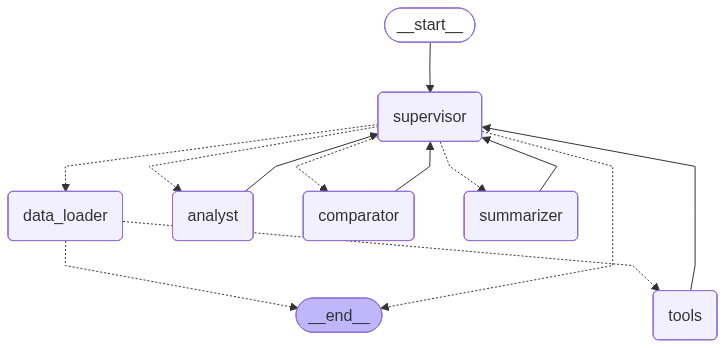

In [28]:
graph

In [29]:
result = graph.invoke(
    {
        "messages": [],
        "file_paths": {
            "HDFC": "stock_files/hdfc.csv",
            "INFY": "stock_files/infy.csv"
        }
    },
    config={"configurable": {"thread_id": "test-run"}}
)


===== STATE DEBUG =====
messages: []
file_paths : {'HDFC': 'stock_files/hdfc.csv', 'INFY': 'stock_files/infy.csv'}

SUPERVISOR DECISION: data_loader
HAS DATA: False
HAS ANALYSIS: False
HAS COMPARISON: False
HAS_REPORT: False

===== STATE DEBUG =====
messages: ['ai']
next_agent : data_loader
file_paths : {'HDFC': 'stock_files/hdfc.csv', 'INFY': 'stock_files/infy.csv'}
current_task : Run stock analysis

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 83, 'total_tokens': 141, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_473ac25fa1', 'id': 'chatcmpl-DNBPOSshQvuv6nwWNBBijGjWIOA9v', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_

In [30]:
result

{'messages': [ToolMessage(content='[1610, 1625, 1630, 1645, 1650]', name='load_stock_data', tool_call_id='call_SiFpM76eRbedbBVdMQ8JzRD2'),
  ToolMessage(content='[1510, 1520, 1515, 1510, 1512]', name='load_stock_data', tool_call_id='call_7IR2SBmOc69q8KjR0hsAzOHa'),
  AIMessage(content='Supervisor: Data ready. Starting analysis...', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='Stock:\nPrices: [1610, 1625, 1630, 1645, 1650]\nMoving Avg: [nan, nan, 1621.6666666666667, 1633.3333333333333, 1641.6666666666667]\nTrend: MODERATE\nSpike: NO SPIKE\n\n\nStock:\nPrices: [1510, 1520, 1515, 1510, 1512]\nMoving Avg: [nan, nan, 1515.0, 1515.0, 1512.3333333333333]\nTrend: MODERATE\nSpike: NO SPIKE\n', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='Supervisor: Analysis complete. Comparing stocks...', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  AIMes

In [31]:
result['final_report']

"The analysis compares two stocks, both exhibiting a moderate upward trend without any spike behavior. \n\nStock 1 demonstrates a clear and steady increase in prices from 1610 to 1650, reflecting stronger growth momentum but with larger absolute price changes, indicating lower stability. In contrast, Stock 2's prices fluctuate modestly between 1510 and 1520, showing greater price stability and smaller variations, albeit with less consistent upward movement.\n\nOverall, Stock 1 offers more pronounced growth potential, while Stock 2 provides a more stable price environment. Neither stock experiences sudden price spikes, suggesting steady and smooth market behavior."

In [32]:
# for step in graph.stream(
#     {
#         "messages": [],
#         "file_paths": {
#             "HDFC": "stock_files/hdfc.csv",
#             "INFY": "stock_files/infy.csv"
#         }
#     },
#     config={"configurable": {"thread_id": "debug-run"}}
# ):
#     print("\nSTEP:", step)

In [35]:
from langgraph.types import StateSnapshot
 
 
# config = {"configurable": {"thread_id": conversation_id_from_user}}
config = {"configurable": {"thread_id": "test-run"}}
 
snapshot = graph.get_state(config)
# print(snapshot)
# _printed = set()
 
 
def _print_event(event: StateSnapshot):
    messages = event.values.get("messages", None)
    if messages:
        if not isinstance(messages, list):
            messages = [messages]
 
        for message in messages:
            message.pretty_print()
            print("\n")
 
 
_print_event(snapshot)

================================= Tool Message =================================
Name: load_stock_data

[1610, 1625, 1630, 1645, 1650]


================================= Tool Message =================================
Name: load_stock_data

[1510, 1520, 1515, 1510, 1512]


================================== Ai Message ==================================

Supervisor: Data ready. Starting analysis...


================================== Ai Message ==================================

Stock:
Prices: [1610, 1625, 1630, 1645, 1650]
Moving Avg: [nan, nan, 1621.6666666666667, 1633.3333333333333, 1641.6666666666667]
Trend: MODERATE
Spike: NO SPIKE


Stock:
Prices: [1510, 1520, 1515, 1510, 1512]
Moving Avg: [nan, nan, 1515.0, 1515.0, 1512.3333333333333]
Trend: MODERATE
Spike: NO SPIKE


================================== Ai Message ==================================

Supervisor: Analysis complete. Comparing stocks...


================================== Ai Message ================================